The plan for this file it to have all the code to go from the different planet spectra to them making a new planet list hopefully in an organsied way so it can all be done from one file. 


This code is a combination of code writen by Archie, Abi and Tamzin. The code was put into one document by Miles but he did not write the original code. 

In [31]:
#--- Imports ---#
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import emcee
import corner as corner
from emcee.moves import DEMove, DESnookerMove
from concurrent.futures import ProcessPoolExecutor
import os


class Statistics:
    """Handles all statistical analysis, MCMC fitting, and visualization."""

    def __init__(self, nwalkers=64, nsteps = 5000, burn=500, use_parallel=True, n_cores=None):
        self.nwalkers = nwalkers
        self.nsteps = nsteps
        self.burn = burn
        self.use_parallel = use_parallel

        if n_cores is None:
            cores = os.cpu_count()
            if cores is not None:
                self.n_cores = cores // 2
        else:
            self.n_cores = n_cores

    # ------------------------------------------------------------------ #
    #  Model & likelihood                                                  #
    # ------------------------------------------------------------------ #

    @staticmethod
    def polynomial_model(x_axis, theta):
        """Vectorized polynomial model."""
        return np.polyval(theta, x_axis)

    @staticmethod
    def log_likelihood(theta, x_axis, y_axis, y_axis_err, xerr=None):
        """
        Log-likelihood accounting for uncertainties on both x and y.
        """
        model = Statistics.polynomial_model(x_axis, theta)
        diff  = y_axis - model

        if xerr is not None:
            ndim = len(theta)
            if ndim == 3:
                dydx = 2 * theta[0] * x_axis + theta[1]
            elif ndim == 2:
                dydx = np.full_like(x_axis, theta[0])
            else:
                deriv_coeffs = np.polyder(theta)
                dydx = np.polyval(deriv_coeffs, x_axis)
            sigma_eff2 = y_axis_err**2 + (dydx * xerr)**2
        else:
            sigma_eff2 = y_axis_err**2

        chi2    = np.sum(diff**2 / sigma_eff2)
        log_det = np.sum(np.log(2 * np.pi * sigma_eff2))
        return -0.5 * (chi2 + log_det)

    @staticmethod
    def log_prior(theta, priors):
        """Vectorized prior check."""
        for param, (low, high) in zip(theta, priors):
            if not (low < param < high):
                return -np.inf
        return 0.0

    @staticmethod
    def log_probability(theta, x_axis, y_axis, y_axis_err, priors, xerr=None):
        """Combined log-posterior with optional x uncertainty."""
        lp = Statistics.log_prior(theta, priors)
        if not np.isfinite(lp):
            return -np.inf
        return lp + Statistics.log_likelihood(theta, x_axis, y_axis, y_axis_err, xerr)

    # ------------------------------------------------------------------ #
    #  Scaling helpers                                                     #
    # ------------------------------------------------------------------ #

    @staticmethod
    def get_smart_scaling(x_axis, y_axis):
        """Centre x around the mean, scale both axes to their max absolute values."""
        x_scale = np.abs(x_axis).max()
        y_scale = np.abs(y_axis).max()
        return x_scale, y_scale

    @staticmethod
    def scale_priors(priors, x_scale):
        """Scale priors to match scaled coordinates."""
        n_params = len(priors)
        if n_params == 3:
            A_low, A_high = priors[0]
            B_low, B_high = priors[1]
            C_low, C_high = priors[2]
            return [
                (A_low * x_scale**2, A_high * x_scale**2),
                (B_low * x_scale,    B_high * x_scale),
                (C_low,              C_high),
            ]
        elif n_params == 2:
            B_low, B_high = priors[0]
            C_low, C_high = priors[1]
            return [
                (B_low * x_scale, B_high * x_scale),
                (C_low,           C_high),
            ]
        return priors

    @staticmethod
    def unscale_samples(samples, x_scale, n_params):
        """Transform samples back to original scale."""
        unscaled = samples.copy()
        if n_params == 3:
            unscaled[:, 0] = samples[:, 0] / (x_scale**2)
            unscaled[:, 1] = samples[:, 1] / x_scale
        elif n_params == 2:
            unscaled[:, 0] = samples[:, 0] / x_scale
        return unscaled

    # ------------------------------------------------------------------ #
    #  Information criteria                                                #
    # ------------------------------------------------------------------ #

    @staticmethod
    def calculate_bic(log_likelihood, n_params, n_data):
        """Calculate Bayesian Information Criterion."""
        return n_params * np.log(n_data) - 2 * log_likelihood

    @staticmethod
    def effective_variance(theta, x_axis, y_axis_err, xerr=None):
        """
        Compute σ_eff² = σ_y² + (dy/dx)² · σ_x² at each data point.
        When xerr is None this just returns σ_y².
        Derived from first-order error propagation: uncertainty in x
        maps onto uncertainty in y via the local gradient of the model.
        """
        if xerr is None:
            return y_axis_err**2

        ndim = len(theta)
        if ndim == 3:                          # quadratic: dy/dx = 2A·x + B
            dydx = 2 * theta[0] * x_axis + theta[1]
        elif ndim == 2:                        # linear:    dy/dx = B
            dydx = np.full_like(x_axis, theta[0])
        else:                                  # general polynomial
            dydx = np.polyval(np.polyder(theta), x_axis)

        return y_axis_err**2 + (dydx * xerr)**2

    @staticmethod
    def calculate_chi_squared(y_data, y_model, yerr, theta=None, x_data=None, xerr=None):
        """
        Calculate chi-squared statistic.
        When theta, x_data, and xerr are all supplied the effective variance
        σ_eff² = σ_y² + (dy/dx)²·σ_x² is used, which is the correct
        denominator when x has measurement uncertainty.
        """
        sigma2 = Statistics.effective_variance(theta, x_data, yerr, xerr) \
                 if (theta is not None and x_data is not None and xerr is not None) \
                 else yerr**2
        return np.sum((y_data - y_model)**2 / sigma2)

    # ------------------------------------------------------------------ #
    #  Walker initialisation                                               #
    # ------------------------------------------------------------------ #

    @staticmethod
    def initialize(priors, nwalkers, x_data, y_data):
        """Initialise walkers using OLS fit as starting guess."""
        ndim = len(priors)
        if ndim == 3:
            p_init = np.polyfit(x_data, y_data, 2)
        elif ndim == 2:
            p_init = np.polyfit(x_data, y_data, 1)
        else:
            p_init = np.polyfit(x_data, y_data, ndim - 1)

        for i, (val, (low, high)) in enumerate(zip(p_init, priors)):
            if not (low < val < high):
                p_init[i] = 0.5 * (low + high)

        pos = np.zeros((nwalkers, ndim))
        for i, (low, high) in enumerate(priors):
            width = high - low
            pos[:, i] = p_init[i] + 0.01 * width * np.random.randn(nwalkers)
            pos[:, i] = np.clip(pos[:, i], low + 1e-10, high - 1e-10)

        return pos, p_init

    # ------------------------------------------------------------------ #
    #  MCMC runner                                                         #
    # ------------------------------------------------------------------ #

    def run_mcmc(self, x_data, y_data, y_data_err, priors,
                 xerr=None, nsteps=None, burn=None,
                 use_smart_scaling=True, progress=True):
        """
        MCMC with optional x uncertainty support.
        Returns (sampler, samples, tau, log_lines) where log_lines is a list
        of strings that will be printed in the final summary.
        """
        ndim = len(priors)
        log_lines = []

        if nsteps is None: nsteps = self.nsteps
        if burn is None: burn = self.burn

        if use_smart_scaling:
            x_scale, y_scale = self.get_smart_scaling(x_data, y_data)
            x_fit    = x_data / x_scale
            xerr_fit = xerr / x_scale if xerr is not None else None
            priors_fit = self.scale_priors(priors, x_scale)

            if xerr is not None:
                log_lines.append(
                    f"✓ Including x uncertainties (mean xerr = {np.mean(xerr):.1f} K)"
                )
                log_lines.append(
                    f"  Mean scaled xerr = {np.mean(xerr_fit):.4f}"
                )
        else:
            x_fit      = x_data
            xerr_fit   = xerr
            x_scale    = 1.0
            priors_fit = priors

        pos, p_init = self.initialize(priors_fit, self.nwalkers, x_fit, y_data)

        moves = [
            (DEMove(),          0.80),
            (DESnookerMove(),   0.15),
            (emcee.moves.StretchMove(), 0.05),
        ]

        sampler = emcee.EnsembleSampler(
            self.nwalkers, ndim, self.log_probability,
            args=(x_fit, y_data, y_data_err, priors_fit, xerr_fit),
            moves=moves,
        )

        # Burn-in
        state = sampler.run_mcmc(pos, burn, progress=progress,
                                 progress_kwargs={"desc": "Burn-in"})
        sampler.reset()

        # Production
        sampler.run_mcmc(state, nsteps, progress=progress,
                         progress_kwargs={"desc": "Production"})

        samples_fit = sampler.get_chain(flat=True)

        if use_smart_scaling:
            samples = self.unscale_samples(samples_fit, x_scale, ndim)
        else:
            samples = samples_fit

        tau = sampler.get_autocorr_time()

        log_lines.append(f"✓ Sampling complete!")
        log_lines.append(f"Autocorrelation time: {tau}")
        log_lines.append(f"Effective samples: {len(samples) / np.max(tau):.0f}")

        return sampler, samples, tau, log_lines

    # ------------------------------------------------------------------ #
    #  Prior suggestion                                                    #
    # ------------------------------------------------------------------ #

    @staticmethod
    def suggest_priors(T_data, y_data, model_type='quadratic', safety_factor=20):
        """
        Generate data-driven priors.
        Returns (priors, log_lines) — log_lines printed in final summary.
        """
        T_min, T_max = T_data.min(), T_data.max()
        y_min, y_max = y_data.min(), y_data.max()
        T_range = T_max - T_min
        y_range = y_max - y_min
        T_mid   = (T_min + T_max) / 2
        y_mid   = (y_min + y_max) / 2
        log_lines = []

        if model_type == 'quadratic':
            A_estimate = y_range / (T_max - T_mid)**2
            B_estimate = y_range / T_range
            C_estimate = y_mid

            A_bound = safety_factor * max(abs(A_estimate), 1e-6)
            B_bound = safety_factor * max(abs(B_estimate), 1.0)
            C_bound = y_mid + safety_factor * y_range

            priors = [
                (-A_bound,  A_bound),
                (-B_bound,  B_bound),
                (-C_bound,  C_bound),
            ]

            log_lines.append("SUGGESTED PRIORS (Quadratic)")
            log_lines.append(f"  A: [{priors[0][0]:.6e}, {priors[0][1]:.6e}]")
            log_lines.append(f"  B: [{priors[1][0]:.3f}, {priors[1][1]:.3f}]")
            log_lines.append(f"  C: [{priors[2][0]:.1f}, {priors[2][1]:.1f}]")

        else:  # linear
            B_estimate = y_range / T_range
            C_estimate = y_mid - B_estimate * T_mid

            B_bound = safety_factor * max(abs(B_estimate), 1.0)
            C_bound = abs(C_estimate) + safety_factor * y_range

            priors = [
                (-B_bound, B_bound),
                (-C_bound, C_bound),
            ]

            log_lines.append("SUGGESTED PRIORS (Linear)")
            log_lines.append(f"  B: [{priors[0][0]:.3f}, {priors[0][1]:.3f}]")
            log_lines.append(f"  C: [{priors[1][0]:.1f}, {priors[1][1]:.1f}]")

        return priors, log_lines

    # ------------------------------------------------------------------ #
    #  Posterior predictive checks                                         #
    # ------------------------------------------------------------------ #

    @staticmethod
    def Mean_absolute_error(y_data, y_model_obs):
        """Calculate Mean Absolute Error."""
        residuals = y_data - y_model_obs
        return 1 / len(residuals) * sum(np.abs(residuals))

    @staticmethod
    def MS_Posterior_Predictive_Check(samples_quad, y_data, y_model_obs, x_data, y_data_err):
        residuals_quad = y_data - y_model_obs
        idx = np.random.choice(len(samples_quad), size=500, replace=False)

        rms_sim = []
        for i in idx:
            A, x0, ymin, log_sigma = samples_quad[i]
            sigma_int = np.exp(log_sigma)
            y_sim = (
                A * (x_data - x0)**2 + ymin
                + np.random.normal(0, y_data_err, size=len(x_data))
                + np.random.normal(0, sigma_int, size=len(x_data))
            )
            y_model_i = A * (x_data - x0)**2 + ymin
            rms_sim.append(np.sqrt(np.mean((y_sim - y_model_i)**2)))

        rms_obs = np.sqrt(np.mean(residuals_quad**2))
        rms_obs_minus_sim = rms_obs - np.mean(rms_sim)
        rms_z_score = rms_obs_minus_sim / np.std(rms_sim)
        return rms_sim, rms_obs, rms_z_score

    @staticmethod
    def curvature_stat(samples_quad, y_data, x, Y_err, rng=np.random.default_rng()):
        """RMS of second finite differences — measures curvature independent of slope/offset."""
        T_curv_obs = np.sqrt(np.mean((y_data[2:] - 2*y_data[1:-1] + y_data[:-2])**2))
        T_curv_sim = []
        idx = np.random.choice(len(samples_quad), size=500, replace=False)

        for i in idx:
            A, x0, ymin, log_sigma = samples_quad[i]
            sigma_int = np.exp(log_sigma)
            y_model_i = A * (x - x0)**2 + ymin
            y_sim = (
                y_model_i
                + rng.normal(0, Y_err)
                + rng.normal(0, sigma_int, size=len(x))
            )
            T_curv_sim.append(np.sqrt(np.mean((y_sim[2:] - 2*y_sim[1:-1] + y_sim[:-2])**2)))

        T_curv_sim = np.array(T_curv_sim)
        curv_mean = np.mean(T_curv_sim)
        curv_std  = np.std(T_curv_sim)
        curv_z    = (T_curv_obs - curv_mean) / curv_std

        return curv_mean, curv_std, curv_z, T_curv_obs, T_curv_sim

    # ------------------------------------------------------------------ #
    #  Diagnostics                                                         #
    # ------------------------------------------------------------------ #

    @staticmethod
    def diagnose_fit(samples, T_data, y_data, yerr_data, model_func,
                     model_name="Model", true_params=None, xerr=None):
        """
        Comprehensive diagnostics for MCMC fit quality.
        Returns (results_dict, log_lines).
        Pass xerr to get χ² computed with the correct effective variance.
        """
        log_lines = []
        log_lines.append(f"DIAGNOSTIC: {model_name}")

        median_params = np.median(samples, axis=0)
        std_params    = np.std(samples, axis=0)

        param_names = ['A', 'B', 'C'] if len(median_params) == 3 else ['B', 'C']
        for i, name in enumerate(param_names):
            log_lines.append(f"  {name}: {median_params[i]:.6e} ± {std_params[i]:.6e}")

        log_lines.append(f"  Any NaN: {np.any(np.isnan(samples))}")
        log_lines.append(f"  Any Inf: {np.any(np.isinf(samples))}")

        y_pred    = model_func(median_params, T_data)
        residuals = y_data - y_pred
        chi2      = Statistics.calculate_chi_squared(
                        y_data, y_pred, yerr_data,
                        theta=median_params, x_data=T_data, xerr=xerr)
        red_chi2  = chi2 / (len(y_data) - len(median_params))

        log_lines.append(f"  Mean residual: {np.mean(residuals):.2f} ± {np.std(residuals):.2f}")

        if true_params is not None:
            log_lines.append("\nComparison to True Values:")
            for i, name in enumerate(param_names):
                true_val  = true_params[i]
                recovered = median_params[i]
                error     = std_params[i]
                sigma_diff = abs(true_val - recovered) / error
                log_lines.append(
                    f"  {name}: True={true_val:.6e}, Recovered={recovered:.6e} ± {error:.6e}"
                )
                log_lines.append(
                    f"      → Difference: {sigma_diff:.2f}σ {'✓' if sigma_diff < 3 else '⚠️'}"
                )

        log_lines.append("\nQuality Assessment:")
        if red_chi2 < 0.5:
            log_lines.append("  ⚠️  Reduced χ² < 0.5: May be overfitting or errors overestimated")
        elif red_chi2 > 2.0:
            log_lines.append("  ⚠️  Reduced χ² > 2.0: Poor fit or errors underestimated")
        else:
            log_lines.append("  ✓ Reduced χ² ≈ 1: Good fit!")

        if np.std(y_pred) < 1e-6:
            log_lines.append("  ⚠️  Predictions are nearly constant - model may not be working")
        else:
            log_lines.append("  ✓ Model produces varying predictions")

        log_lines.append("=" * 70)

        return {
            'median_params': median_params,
            'std_params':    std_params,
            'chi2':          chi2,
            'red_chi2':      red_chi2,
            'residuals':     residuals,
        }, log_lines

    # ------------------------------------------------------------------ #
    #  Corner plot                                                         #
    # ------------------------------------------------------------------ #

    @staticmethod
    def make_corner_plot(sampler_or_samples, labels, burn=1000, thin=1,
                         title="Posterior", print_map=True, print_autocorr=True,
                         truths=None):
        """
        Create a corner plot from either an emcee sampler or a numpy samples array.
        Returns (flat_samples, flat_logprob, log_lines).
        """
        log_lines = []

        if isinstance(sampler_or_samples, np.ndarray):
            flat_samples = sampler_or_samples
            flat_logprob = None
            print_autocorr = False
            log_lines.append("(Received samples array directly)")
        else:
            sampler      = sampler_or_samples
            flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
            flat_logprob = sampler.get_log_prob(discard=burn, thin=thin, flat=True)

        fig = corner.corner(
            flat_samples[:, :len(labels)],
            labels=labels,
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
            title_fmt=".4g",
            title_kwargs={"fontsize": 12},
            truths=truths,
        )
        fig.suptitle(title, fontsize=14, y=1.00)
        plt.tight_layout()
        plt.show()

        if print_map and flat_logprob is not None:
            imax      = np.argmax(flat_logprob)
            theta_map = flat_samples[imax, :len(labels)]
            log_lines.append("MAP (Maximum A Posteriori) Estimate:")
            for name, val in zip(labels, theta_map):
                log_lines.append(f"  {name:15s} = {val:.6g}")
        elif print_map:
            theta_median = np.median(flat_samples[:, :len(labels)], axis=0)
            theta_std    = np.std(flat_samples[:, :len(labels)], axis=0)
            log_lines.append("Posterior Median Estimates:")
            for name, med, std in zip(labels, theta_median, theta_std):
                log_lines.append(f"  {name:15s} = {med:.6g} ± {std:.6g}")

        if print_autocorr and not isinstance(sampler_or_samples, np.ndarray):
            try:
                tau = sampler_or_samples.get_autocorr_time()
                log_lines.append(f"Autocorrelation time: {tau}")
            except Exception:
                log_lines.append("Could not estimate autocorrelation time (chain may be too short).")

        return flat_samples, flat_logprob, log_lines

    # ------------------------------------------------------------------ #
    #  Posterior fit plot                                                  #
    # ------------------------------------------------------------------ #

    @staticmethod
    def plot_posterior_fits(x_data, y_data, yerr_data, samples, model_func,
                        title="Posterior Fits", n_draws=100, show_cloud=True,
                        xerr=None):
        """
        Plot data with posterior predictive distribution and credible intervals.
        Pass xerr so that chi², BIC, and normalised residuals all use the
        correct effective variance σ_eff² = σ_y² + (dy/dx)²·σ_x².

        Layout: three panels (3:2:1 height ratio)
        1. Main fit with credible bands
        2. Normalised residuals
        3. Text panel with posterior params + fit statistics
        """
        median_params = np.median(samples, axis=0)
        y_pred    = model_func(median_params, x_data)
        chi2      = Statistics.calculate_chi_squared(
                        y_data, y_pred, yerr_data,
                        theta=median_params, x_data=x_data, xerr=xerr)
        red_chi2  = chi2 / (len(y_data) - len(median_params))
        # compute the true log‑likelihood including normalization term
        logL      = Statistics.log_likelihood(median_params, x_data, y_data,
                                              yerr_data, xerr)
        BIC       = Statistics.calculate_bic(logL, samples.shape[1], len(y_data))

        fig, (ax1, ax2, ax3) = plt.subplots(
            3, 1, figsize=(12, 10),
            gridspec_kw={'height_ratios': [3, 2, 1]},
        )

        T_plot = np.linspace(
            x_data.min() - 0.05 * (x_data.max() - x_data.min()),
            x_data.max() + 0.05 * (x_data.max() - x_data.min()),
            300,
        )

        # Subsample ONCE before building any arrays — avoids materialising
        # the full (n_samples × n_plot_points) matrix which can be hundreds of MB.
        n_posterior = min(n_draws, len(samples))
        idx_post    = np.random.choice(len(samples), n_posterior, replace=False)
        samples_sub = samples[idx_post]

        y_posterior = np.array([model_func(params, T_plot) for params in samples_sub])
        y_median = np.median(y_posterior, axis=0)
        y_16     = np.percentile(y_posterior, 16,  axis=0)
        y_84     = np.percentile(y_posterior, 84,  axis=0)
        y_025    = np.percentile(y_posterior,  2.5, axis=0)
        y_975    = np.percentile(y_posterior, 97.5, axis=0)

        # ── Panel 1: main fit ────────────────────────────────────────────────────
        ax1.fill_between(T_plot, y_025, y_975, color='yellow', alpha=0.3,
                        label='95% credible interval', zorder=1)
        ax1.fill_between(T_plot, y_16,  y_84,  color='orange', alpha=0.4,
                        label='68% credible interval', zorder=2)

        if show_cloud:
            for row in y_posterior:
                ax1.plot(T_plot, row, color='coral', alpha=0.05, lw=0.8, zorder=3)

        ax1.plot(T_plot, y_median, color='darkblue', lw=3,
                label='Posterior median', zorder=10)
        ax1.errorbar(x_data, y_data, yerr=yerr_data,
                    xerr=xerr,
                    fmt='o', color='black',
                    label='Data', markersize=8, capsize=4, elinewidth=2,
                    markeredgecolor='white', markeredgewidth=1, zorder=15)

        ax1.set_xlabel("Temperature (K)",  fontsize=16, fontweight='bold')
        ax1.set_ylabel("$B_H$",            fontsize=16, fontweight='bold')
        ax1.set_title(title,               fontsize=22, fontweight='bold', pad=15)
        ax1.legend(fontsize=11, loc='best', framealpha=0.9)
        ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        # ── Panel 2: normalised residuals ────────────────────────────────────────
        y_data_pred          = model_func(median_params, x_data)
        residuals            = y_data - y_data_pred
        sigma_eff            = np.sqrt(Statistics.effective_variance(
                                median_params, x_data, yerr_data, xerr))
        normalized_residuals = residuals / sigma_eff

        ax2.axhline(0,  color='blue', linestyle='--', lw=2,   alpha=0.7, label='Zero')
        ax2.axhline(2,  color='red',  linestyle=':',  lw=1.5, alpha=0.5)
        ax2.axhline(-2, color='red',  linestyle=':',  lw=1.5, alpha=0.5, label='±2σ')
        ax2.fill_between([min(T_plot), max(T_plot)], -1, 1,
                        color='green', alpha=0.15, label='±1σ')
        ax2.errorbar(x_data, normalized_residuals, yerr=1.0,
                    xerr=xerr,
                    fmt='o', color='black',
                    markersize=7, capsize=3, elinewidth=1.5)

        mean_res = np.mean(normalized_residuals)
        std_res  = np.std(normalized_residuals)
        ax2.set_xlabel("Temperature (K)",                              fontsize=12, fontweight='bold')
        ax2.set_ylabel("Normalised Residuals\n(Data − Model) / Error", fontsize=11, fontweight='bold')
        ax2.legend(fontsize=12, loc='best')
        ax2.grid(alpha=0.3, linestyle='--')

        # ── Panel 3: parameter / statistics table ────────────────────────────────
        ax3.axis('off')

        std_params = np.std(samples, axis=0)
        if len(median_params) == 3:
            param_lines = (
                f"A = {median_params[0]:.4e} ± {std_params[0]:.2e}     "
                f"B = {median_params[1]:.4e} ± {std_params[1]:.2e}     "
                f"C = {median_params[2]:.2f} ± {std_params[2]:.2f}"
            )
        else:
            param_lines = (
                f"B = {median_params[0]:.4e} ± {std_params[0]:.2e}     "
                f"C = {median_params[1]:.2f} ± {std_params[1]:.2f}"
            )

        stats_line = (
            f"χ² = {chi2:.2f}     "
            f"Reduced χ² = {red_chi2:.3f}     "
            f"BIC = {BIC:.2f}     "
            f"Residuals — mean: {mean_res:.2f}  std: {std_res:.2f}"
        )

        ax3.text(0.5, 0.65, "Posterior median ± σ:  " + param_lines,
                transform=ax3.transAxes, fontsize=12, family='monospace',
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
        ax3.text(0.5, 0.2, stats_line,
                transform=ax3.transAxes, fontsize=12, family='monospace',
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

        plt.tight_layout()
        plt.show()
        return fig

    # def plot_posterior_fits(x_data, y_data, yerr_data, samples, model_func,
    #                         title="Posterior Fits", n_draws=100, show_cloud=True,
    #                         xerr=None):
    #     """
    #     Plot data with posterior predictive distribution and credible intervals.
    #     Pass xerr so that chi², BIC, and normalised residuals all use the
    #     correct effective variance σ_eff² = σ_y² + (dy/dx)²·σ_x².
    #     """
    #     median_params = np.median(samples, axis=0)
    #     y_pred    = model_func(median_params, x_data)
    #     chi2      = Statistics.calculate_chi_squared(
    #     # use proper log-likelihood rather than just -0.5*chi2
    #     logL = Statistics.log_likelihood(np.median(samples, axis=0),
    #                                       x_data, y_data, yerr_data, xerr)
    #     BIC       = Statistics.calculate_bic(logL, samples.shape[1], len(y_data))

    #     fig, (ax1, ax2) = plt.subplots(
    #         2, 1, figsize=(12, 8),
    #         gridspec_kw={'height_ratios': [2, 1]},
    #     )

    #     T_plot = np.linspace(
    #         x_data.min() - 0.05 * (x_data.max() - x_data.min()),
    #         x_data.max() + 0.05 * (x_data.max() - x_data.min()),
    #         300,
    #     )

    #     # Subsample ONCE before building any arrays — avoids materialising
    #     # the full (n_samples × n_plot_points) matrix which can be hundreds of MB.
    #     n_posterior = min(n_draws, len(samples))
    #     idx_post    = np.random.choice(len(samples), n_posterior, replace=False)
    #     samples_sub = samples[idx_post]

    #     y_posterior = np.array([model_func(params, T_plot) for params in samples_sub])
    #     y_median = np.median(y_posterior, axis=0)
    #     y_16     = np.percentile(y_posterior, 16,  axis=0)
    #     y_84     = np.percentile(y_posterior, 84,  axis=0)
    #     y_025    = np.percentile(y_posterior,  2.5, axis=0)
    #     y_975    = np.percentile(y_posterior, 97.5, axis=0)

    #     ax1.fill_between(T_plot, y_025, y_975, color='yellow', alpha=0.3,
    #                      label='95% credible interval', zorder=1)
    #     ax1.fill_between(T_plot, y_16,  y_84,  color='orange', alpha=0.4,
    #                      label='68% credible interval', zorder=2)

    #     if show_cloud:
    #         for row in y_posterior:          # already the subsampled set
    #             ax1.plot(T_plot, row, color='coral', alpha=0.05, lw=0.8, zorder=3)

    #     ax1.plot(T_plot, y_median, color='darkblue', lw=3,
    #              label='Posterior median', zorder=10)
    #     ax1.errorbar(x_data, y_data, yerr=yerr_data,
    #                  xerr=xerr,          # x uncertainties shown when provided
    #                  fmt='o', color='black',
    #                  label='Data', markersize=8, capsize=4, elinewidth=2,
    #                  markeredgecolor='white', markeredgewidth=1, zorder=15)

    #     std_params = np.std(samples, axis=0)
    #     param_text = "Posterior median ± σ:\n"
    #     if len(median_params) == 3:
    #         param_text += f"A = {median_params[0]:.4e} ± {std_params[0]:.2e}\n"
    #         param_text += f"B = {median_params[1]:.4e} ± {std_params[1]:.2e}\n"
    #         param_text += f"C = {median_params[2]:.2f} ± {std_params[2]:.2f}"
    #         param_text += f"\n\nχ² = {chi2:.2f}\nReduced χ² = {red_chi2:.3f}\nBIC = {BIC:.2f}"
    #     else:
    #         param_text += f"B = {median_params[0]:.4e} ± {std_params[0]:.2e}\n"
    #         param_text += f"C = {median_params[1]:.2f} ± {std_params[1]:.2f}"
    #         param_text += f"\n\nχ² = {chi2:.2f}\nReduced χ² = {red_chi2:.3f}\nBIC = {BIC:.2f}"

    #     ax1.text(0.98, 0.02, param_text, transform=ax1.transAxes,
    #              fontsize=16, verticalalignment='top', family='monospace',
    #              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    #     ax1.set_xlabel("Temperature (K)",   fontsize=16, fontweight='bold')
    #     ax1.set_ylabel("$B_H$",    fontsize=16, fontweight='bold')
    #     ax1.set_title(title,                fontsize=22, fontweight='bold', pad=15)
    #     ax1.legend(fontsize=11, loc='best', framealpha=0.9)
    #     ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)

    #     y_data_pred          = model_func(np.median(samples, axis=0), x_data)
    #     residuals            = y_data - y_data_pred
    #     sigma_eff            = np.sqrt(Statistics.effective_variance(
    #                                median_params, x_data, yerr_data, xerr))
    #     normalized_residuals = residuals / sigma_eff

    #     ax2.axhline(0,   color='blue', linestyle='--', lw=2,   alpha=0.7, label='Zero')
    #     ax2.axhline(2,   color='red',  linestyle=':',  lw=1.5, alpha=0.5)
    #     ax2.axhline(-2,  color='red',  linestyle=':',  lw=1.5, alpha=0.5, label='±2σ')
    #     ax2.fill_between([min(x_data), max(x_data)], -1, 1, color='green', alpha=0.15, label='±1σ')
    #     ax2.errorbar(x_data, normalized_residuals, yerr=1.0,
    #                  xerr=xerr,          # x uncertainties shown when provided
    #                  fmt='o', color='black',
    #                  markersize=7, capsize=3, elinewidth=1.5)

    #     ax2.set_xlabel("Temperature (K)",                           fontsize=12, fontweight='bold')
    #     ax2.set_ylabel("Normalized Residuals\n(Data - Model) / Error", fontsize=11, fontweight='bold')
    #     ax2.legend(fontsize=12, loc='best')
    #     ax2.grid(alpha=0.3, linestyle='--')

    #     mean_res  = np.mean(normalized_residuals)
    #     std_res   = np.std(normalized_residuals)
    #     stats_text = f"Mean: {mean_res:.2f}\nStd: {std_res:.2f}"
    #     ax2.text(0.97, 0.97, stats_text, transform=ax2.transAxes,
    #              fontsize=12, verticalalignment='top', horizontalalignment='right',
    #              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    #     plt.tight_layout()
    #     plt.show()
    #     return fig

    # ------------------------------------------------------------------ #
    #  BIC interpretation                                                  #
    # ------------------------------------------------------------------ #

    @staticmethod
    def interpret_delta_bic(delta_bic):
        """Interpret BIC difference."""
        if delta_bic < -10:
            return "Very strong evidence for more complex model"
        elif delta_bic < -6:
            return "Strong evidence for more complex model"
        elif delta_bic < -2:
            return "Positive evidence for more complex model"
        elif delta_bic < 2:
            return "No meaningful preference between models"
        else:
            return "Simpler model preferred"

    # ------------------------------------------------------------------ #
    #  Model comparison                                                    #
    # ------------------------------------------------------------------ #

    @staticmethod
    def compare_models(x_data, y_data, yerr_data,
                       samples_lin, samples_quad, stats_obj, xerr=None):
        """
        Comprehensive model comparison between linear and quadratic models.
        Pass xerr so that log-likelihoods, BIC, and chi-squared all use the
        correct effective variance sigma_eff^2 = sigma_y^2 + (dy/dx)^2 * sigma_x^2.
        Returns (results_dict, log_lines).
        """
        log_lines = []
        n_data    = len(x_data)

        lin_med  = np.median(samples_lin,  axis=0)
        quad_med = np.median(samples_quad, axis=0)

        if hasattr(stats_obj, 'log_likelihood_optimized'):
            logL_lin  = stats_obj.log_likelihood_optimized(lin_med,  x_data, y_data, yerr_data, xerr)
            logL_quad = stats_obj.log_likelihood_optimized(quad_med, x_data, y_data, yerr_data, xerr)
        elif hasattr(stats_obj, 'log_likelihood'):
            logL_lin  = stats_obj.log_likelihood(lin_med,  x_data, y_data, yerr_data, xerr)
            logL_quad = stats_obj.log_likelihood(quad_med, x_data, y_data, yerr_data, xerr)
        else:
            raise AttributeError("stats_obj has no log_likelihood method!")

        bic_lin   = Statistics.calculate_bic(logL_lin,  2, n_data)
        bic_quad  = Statistics.calculate_bic(logL_quad, 3, n_data)
        delta_bic = bic_quad - bic_lin

        y_lin  = lin_med[0]  * x_data + lin_med[1]
        y_quad = quad_med[0] * x_data**2 + quad_med[1] * x_data + quad_med[2]

        chi2_lin  = Statistics.calculate_chi_squared(
                        y_data, y_lin,  yerr_data, theta=lin_med,  x_data=x_data, xerr=xerr)
        chi2_quad = Statistics.calculate_chi_squared(
                        y_data, y_quad, yerr_data, theta=quad_med, x_data=x_data, xerr=xerr)

        red_chi2_lin  = chi2_lin  / (n_data - 2)
        red_chi2_quad = chi2_quad / (n_data - 3)

        log_lines.append("MODEL COMPARISON RESULTS")
        log_lines.append("\nBayesian Information Criterion:")
        log_lines.append(f"  Linear:    BIC = {bic_lin:.2f}")
        log_lines.append(f"  Quadratic: BIC = {bic_quad:.2f}")
        log_lines.append(f"  ΔBIC (quad - lin) = {delta_bic:.2f}")
        log_lines.append(f"\nInterpretation: {Statistics.interpret_delta_bic(delta_bic)}")
        log_lines.append(f"\nGoodness of Fit:")
        log_lines.append(f"  Linear:    χ² = {chi2_lin:.2f},  χ²_red = {red_chi2_lin:.3f}")
        log_lines.append(f"  Quadratic: χ² = {chi2_quad:.2f}, χ²_red = {red_chi2_quad:.3f}")

        return {
            'bic_lin':       bic_lin,
            'bic_quad':      bic_quad,
            'delta_bic':     delta_bic,
            'chi2_lin':      chi2_lin,
            'chi2_quad':     chi2_quad,
            'red_chi2_lin':  red_chi2_lin,
            'red_chi2_quad': red_chi2_quad,
        }, log_lines

    # ------------------------------------------------------------------ #
    #  Constraining power                                                  #
    # ------------------------------------------------------------------ #

    @staticmethod
    def rank_constraining_points_linear(x_data, yerr):
        """Rank points by how much they constrain the linear slope."""
        T_pivot = np.mean(x_data)
        Tc      = x_data - T_pivot
        weights = 1.0 / yerr**2
        power   = weights * Tc**2
        order   = np.argsort(power)[::-1]
        return order, power, T_pivot

    @staticmethod
    def rank_constraining_points_quadratic(x_data, yerr):
        """Rank points by how much they constrain the quadratic curvature."""
        T_pivot = np.mean(x_data)
        Tc      = x_data - T_pivot
        weights = 1.0 / yerr**2
        power   = weights * Tc**4
        order   = np.argsort(power)[::-1]
        return order, power

    @staticmethod
    def analyze_constraining_power(x_data, yerr, n_top=5):
        """
        Full constraining power analysis for both linear and quadratic models.
        Returns (results_dict, log_lines).
        """
        log_lines = []

        order_l, power_l, T_pivot = Statistics.rank_constraining_points_linear(x_data, yerr)
        order_q, power_q           = Statistics.rank_constraining_points_quadratic(x_data, yerr)

        log_lines.append("=" * 70)
        log_lines.append("CONSTRAINING POWER ANALYSIS")
        log_lines.append("=" * 70)
        log_lines.append(f"\nPivot temperature: {T_pivot:.1f} K")
        log_lines.append("(Points far from pivot with low errors constrain parameters most)\n")

        log_lines.append(f"TOP {n_top} CONSTRAINING POINTS — LINEAR SLOPE")
        log_lines.append("-" * 55)
        log_lines.append(f"  {'Rank':<6} {'T (K)':<10} {'yerr':<10} {'Power':<12} {'Dist from pivot'}")
        log_lines.append("-" * 55)
        for rank, i in enumerate(order_l[:n_top], start=1):
            dist = abs(x_data[i] - T_pivot)
            log_lines.append(
                f"  {rank:<6} {x_data[i]:<10.1f} {yerr[i]:<10.3f} "
                f"{power_l[i]:<12.3e} {dist:.1f} K"
            )

        log_lines.append(f"\nTOP {n_top} CONSTRAINING POINTS — QUADRATIC CURVATURE")
        log_lines.append("-" * 55)
        log_lines.append(f"  {'Rank':<6} {'T (K)':<10} {'yerr':<10} {'Power':<12} {'Dist from pivot'}")
        log_lines.append("-" * 55)
        for rank, i in enumerate(order_q[:n_top], start=1):
            dist = abs(x_data[i] - T_pivot)
            log_lines.append(
                f"  {rank:<6} {x_data[i]:<10.1f} {yerr[i]:<10.3f} "
                f"{power_q[i]:<12.3e} {dist:.1f} K"
            )

        log_lines.append("=" * 70)

        return {
            'order_linear':    order_l,
            'power_linear':    power_l,
            'order_quadratic': order_q,
            'power_quadratic': power_q,
            'T_pivot':         T_pivot,
        }, log_lines

    @staticmethod
    def plot_constraining_power(x_data, yerr, n_top=8):
        """Visualise constraining power for all points with a colourmap."""
        order_l, power_l, T_pivot = Statistics.rank_constraining_points_linear(x_data, yerr)
        order_q, power_q           = Statistics.rank_constraining_points_quadratic(x_data, yerr)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        for ax, order, power, subtitle in [
            (ax1, order_l, power_l, "Linear Slope"),
            (ax2, order_q, power_q, "Quadratic Curvature"),
        ]:
            norm    = plt.Normalize(vmin=power.min(), vmax=power.max())
            cmap    = plt.cm.RdYlGn

            sc = ax.scatter(
                x_data, power,
                c=power, cmap=cmap, norm=norm,
                s=80, zorder=2,
                edgecolors='grey', linewidths=0.5,
                label='All points',
            )
            plt.colorbar(sc, ax=ax, label='Constraining Power')

            for rank, i in enumerate(order[:n_top], start=1):
                ax.scatter(
                    x_data[i], power[i],
                    s=200, facecolors='none',
                    edgecolors='black', linewidths=2.5, zorder=4,
                )
                ax.annotate(
                    f'#{rank}',
                    (x_data[i], power[i]),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=16, fontweight='bold', color='black', zorder=5,
                )

            ax.axvline(T_pivot, color='blue', linestyle='--', alpha=0.6,
                       linewidth=1.5, label=f'Pivot ({T_pivot:.0f} K)')
            ax.set_xlabel("Temperature (K)",    fontsize=14, fontweight='bold')
            ax.set_ylabel("Constraining Power", fontsize=14, fontweight='bold')
            ax.set_title(
                f"Constraining Power — {subtitle}\n(Top {n_top} circled)",
                fontsize=20, fontweight='bold',
            )
            ax.legend(fontsize=12)
            ax.grid(alpha=0.3, linestyle='--')

        plt.suptitle("Constraining Power Analysis", fontsize=30, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        return fig

    # ------------------------------------------------------------------ #
    #  Master analysis routine                                             #
    # ------------------------------------------------------------------ #

    @staticmethod
    def run_all_analysis(data,stats):
        """
        Run the full pipeline. Progress bars show during sampling.
        A single clean summary is printed after all plots.
        """
        #stats = Statistics(nwalkers=64, use_parallel=False)

        T_eq               = data[:, 0]
        T_eq_err           = data[:, 1]
        feature_height     = data[:, 2]
        feature_height_err = data[:, 3]

        # ---- Suggest priors (discard log output) -------------------- #
        priors_quad, _ = stats.suggest_priors(
            T_eq, feature_height, model_type='quadratic', safety_factor=20
        )
        priors_lin, _ = stats.suggest_priors(
            T_eq, feature_height, model_type='linear', safety_factor=20
        )

        # ---- Quadratic MCMC ----------------------------------------- #
        _, samples_quad, tau_quad, _ = stats.run_mcmc(
            x_data=T_eq,
            y_data=feature_height,
            y_data_err=feature_height_err,
            xerr=T_eq_err,
            priors=priors_quad,
        )

        # ---- Quadratic corner + fit plots ---------------------------- #
        stats.make_corner_plot(
            samples_quad,
            labels=[r"$A$", r"$B$", r"$C$"],
            title="Quadratic Model Posterior Distribution",
            truths=None,
        )
        stats.plot_posterior_fits(
            T_eq, feature_height, feature_height_err,
            samples_quad,
            lambda p, T: p[0]*T**2 + p[1]*T + p[2],
            title="Quadratic Model: Posterior Fits with Credible Intervals",
            n_draws=200, show_cloud=True, xerr=T_eq_err,
        )

        # ---- Linear MCMC -------------------------------------------- #
        _, samples_lin, tau_lin, _ = stats.run_mcmc(
            x_data=T_eq,
            y_data=feature_height,
            y_data_err=feature_height_err,
            xerr=T_eq_err,
            priors=priors_lin,
        )

        # ---- Linear fit plot ---------------------------------------- #
        stats.plot_posterior_fits(
            T_eq, feature_height, feature_height_err,
            samples_lin,
            lambda p, T: p[0]*T + p[1],
            title="Linear Model: Posterior Fits with Credible Intervals",
            n_draws=200, show_cloud=True, xerr=T_eq_err,
        )

        # ---- Model comparison plot ---------------------------------- #
        comparison_results, _ = stats.compare_models(
            T_eq, feature_height, feature_height_err,
            samples_lin, samples_quad, stats, xerr=T_eq_err,
        )

        # ---- Constraining power plot -------------------------------- #
        constraining_results, _ = stats.analyze_constraining_power(
            x_data=T_eq, yerr=feature_height_err, n_top=5,
        )
        stats.plot_constraining_power(x_data=T_eq, yerr=feature_height_err)

        # ---- Posterior predictive checks (quadratic) ---------------- #
        quad_med  = np.median(samples_quad, axis=0)
        y_quad    = quad_med[0]*T_eq**2 + quad_med[1]*T_eq + quad_med[2]
        residuals = feature_height - y_quad

        rms_obs   = np.sqrt(np.mean(residuals**2))
        mae       = Statistics.Mean_absolute_error(feature_height, y_quad)

        # ------------------------------------------------------------------
        # Posterior Predictive Checks
        # Each simulated dataset is generated by:
        #   1. Drawing a posterior sample (A, B, C)
        #   2. Perturbing each observed temperature by its x-uncertainty:
        #        T_sim = T_obs + N(0, σ_T)   ← this is the new step
        #   3. Evaluating the model at the perturbed temperatures
        #   4. Adding y-noise: y_sim = model(T_sim) + N(0, σ_y)
        # This correctly marginalises over x uncertainty in the PPCs,
        # consistent with how xerr enters the likelihood during sampling.
        # ------------------------------------------------------------------

        T_curv_obs = np.sqrt(np.mean(
            (feature_height[2:] - 2*feature_height[1:-1] + feature_height[:-2])**2
        ))

        idx = np.random.choice(len(samples_quad), size=500, replace=False)
        T_curv_sim = []
        rms_sim    = []
        rng = np.random.default_rng()

        for i in idx:
            A, B, C = samples_quad[i]

            # Perturb x positions by their measurement uncertainty
            T_sim     = T_eq + rng.normal(0, T_eq_err)

            # Model evaluated at perturbed temperatures
            y_model_i = A*T_sim**2 + B*T_sim + C

            # Add y measurement noise
            y_sim     = y_model_i + rng.normal(0, feature_height_err)

            # Curvature statistic on simulated data
            T_curv_sim.append(np.sqrt(np.mean(
                (y_sim[2:] - 2*y_sim[1:-1] + y_sim[:-2])**2
            )))

            # RMS between simulated data and the model at perturbed x
            rms_sim.append(np.sqrt(np.mean((y_sim - y_model_i)**2)))

        T_curv_sim  = np.array(T_curv_sim)
        curv_mean   = np.mean(T_curv_sim)
        curv_std    = np.std(T_curv_sim)
        curv_z      = (T_curv_obs - curv_mean) / curv_std

        rms_sim     = np.array(rms_sim)
        rms_mean    = np.mean(rms_sim)
        rms_std     = np.std(rms_sim)
        rms_z       = (rms_obs - rms_mean) / rms_std

        # Mean squared residuals
        msr = np.mean(residuals**2)

        # Effective samples
        eff_quad = int(len(samples_quad) / np.max(tau_quad))
        eff_lin  = int(len(samples_lin)  / np.max(tau_lin))

        # Constraining power ranks
        order_l = constraining_results['order_linear']
        order_q = constraining_results['order_quadratic']
        T_pivot = constraining_results['T_pivot']

        # ================================================================ #
        #  SINGLE PRINTED SUMMARY                                          #
        # ================================================================ #
        S = "=" * 70
        s = "-" * 70

        print(f"\n{S}")
        print("RESULTS SUMMARY")
        print(S)

        # --- Quadratic model ----------------------------------------- #
        print("\nQUADRATIC MODEL  (A·T² + B·T + C)")
        print(s)
        print(f"  A = {np.median(samples_quad[:,0]):.4e} ± {np.std(samples_quad[:,0]):.2e}")
        print(f"  B = {np.median(samples_quad[:,1]):.4e} ± {np.std(samples_quad[:,1]):.2e}")
        print(f"  C = {np.median(samples_quad[:,2]):.4f} ± {np.std(samples_quad[:,2]):.4f}")
        print(f"  Reduced χ²          : {comparison_results['red_chi2_quad']:.3f}")
        print(f"  BIC                 : {comparison_results['bic_quad']:.2f}")
        print(f"  Effective samples   : {eff_quad}")

        # --- Linear model -------------------------------------------- #
        print("\nLINEAR MODEL  (B·T + C)")
        print(s)
        print(f"  B = {np.median(samples_lin[:,0]):.4e} ± {np.std(samples_lin[:,0]):.2e}")
        print(f"  C = {np.median(samples_lin[:,1]):.4f} ± {np.std(samples_lin[:,1]):.4f}")
        print(f"  Reduced χ²          : {comparison_results['red_chi2_lin']:.3f}")
        print(f"  BIC                 : {comparison_results['bic_lin']:.2f}")
        print(f"  Effective samples   : {eff_lin}")

        # --- Model comparison ---------------------------------------- #
        print("\nMODEL COMPARISON")
        print(s)
        print(f"  ΔBIC (quad − lin)   : {comparison_results['delta_bic']:.2f}")
        print(f"  Interpretation      : {stats.interpret_delta_bic(comparison_results['delta_bic'])}")
        verdict = "✓ Quadratic preferred" if comparison_results['delta_bic'] < -2 \
                  else "⚠️  Linear sufficient"
        print(f"  Verdict             : {verdict}")

        # --- Posterior predictive checks ----------------------------- #
        print("\nPOSTERIOR PREDICTIVE CHECKS  (quadratic)")
        print(s)
        print(f"  MAE                 : {mae:.4f}")
        print(f"  Mean sq. residuals  : {msr:.4f}")
        print(f"  RMS observed        : {rms_obs:.4f}")
        print(f"  RMS simulated       : {rms_mean:.4f} ± {rms_std:.4f}")
        print(f"  RMS z-score         : {rms_z:.3f}")
        print(f"  Curvature observed  : {T_curv_obs:.4f}")
        print(f"  Curvature simulated : {curv_mean:.4f} ± {curv_std:.4f}")
        print(f"  Curvature z-score   : {curv_z:.3f}  (|z| ≤ 2 → shape OK)")

        # --- Constraining power -------------------------------------- #
        print("\nCONSTRAINING POWER")
        print(s)
        print(f"  Pivot temperature   : {T_pivot:.1f} K")
        print(f"  Top 5 for linear slope      (indices): {order_l[:5].tolist()}")
        print(f"    T values: {[round(float(T_eq[i]),1) for i in order_l[:5]]}")
        print(f"  Top 5 for quad. curvature   (indices): {order_q[:5].tolist()}")
        print(f"    T values: {[round(float(T_eq[i]),1) for i in order_q[:5]]}")

        print(f"\n{S}\n")

TRUE MODEL PARAMETERS
A (curvature) = 3.000000e-03
B (linear)    = -3.000000
C (offset)    = 800.00
Mean uncertainty: 63.48 ppm
Signal-to-noise ratio: 3.8


Production: 100%|██████████| 3000/3000 [00:06<00:00, 444.03it/s]


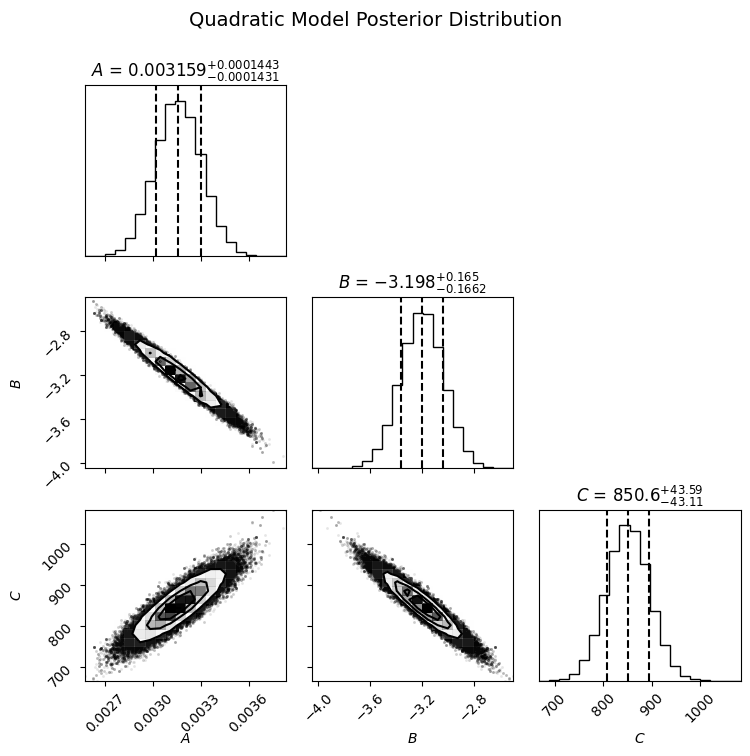

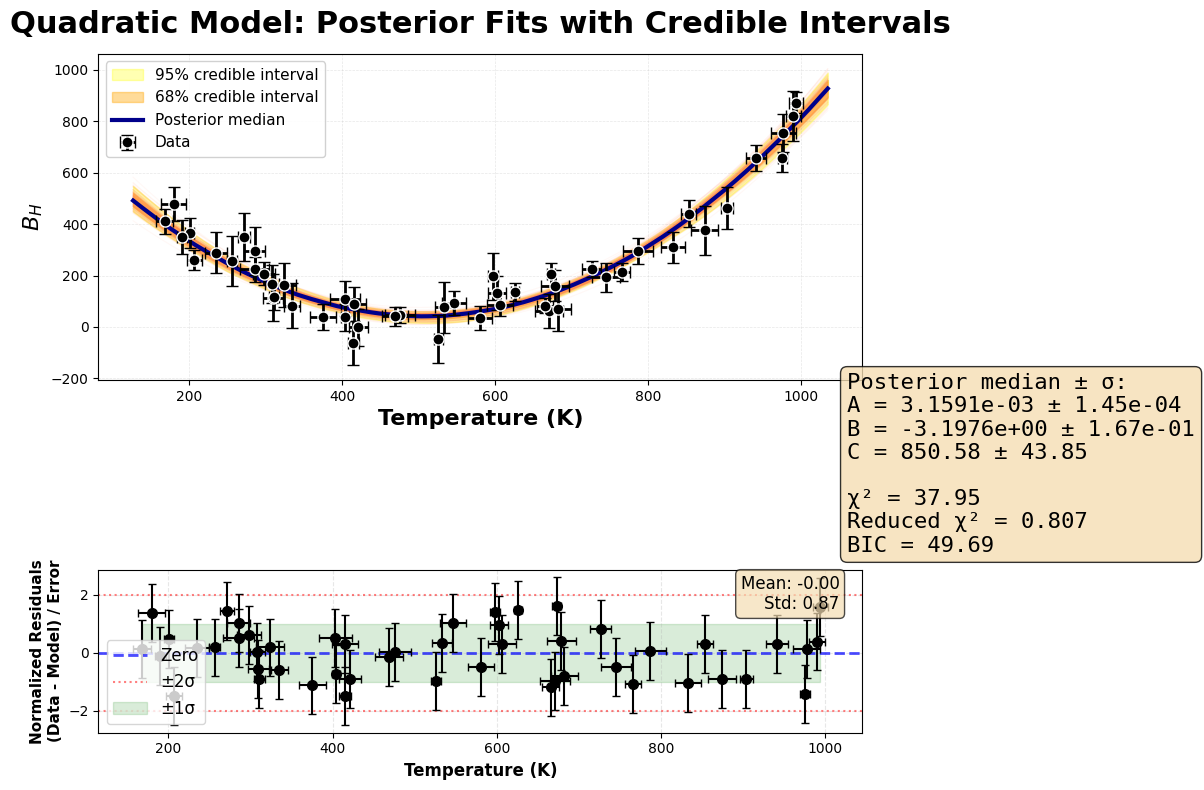

Production: 100%|██████████| 3000/3000 [00:06<00:00, 446.69it/s]


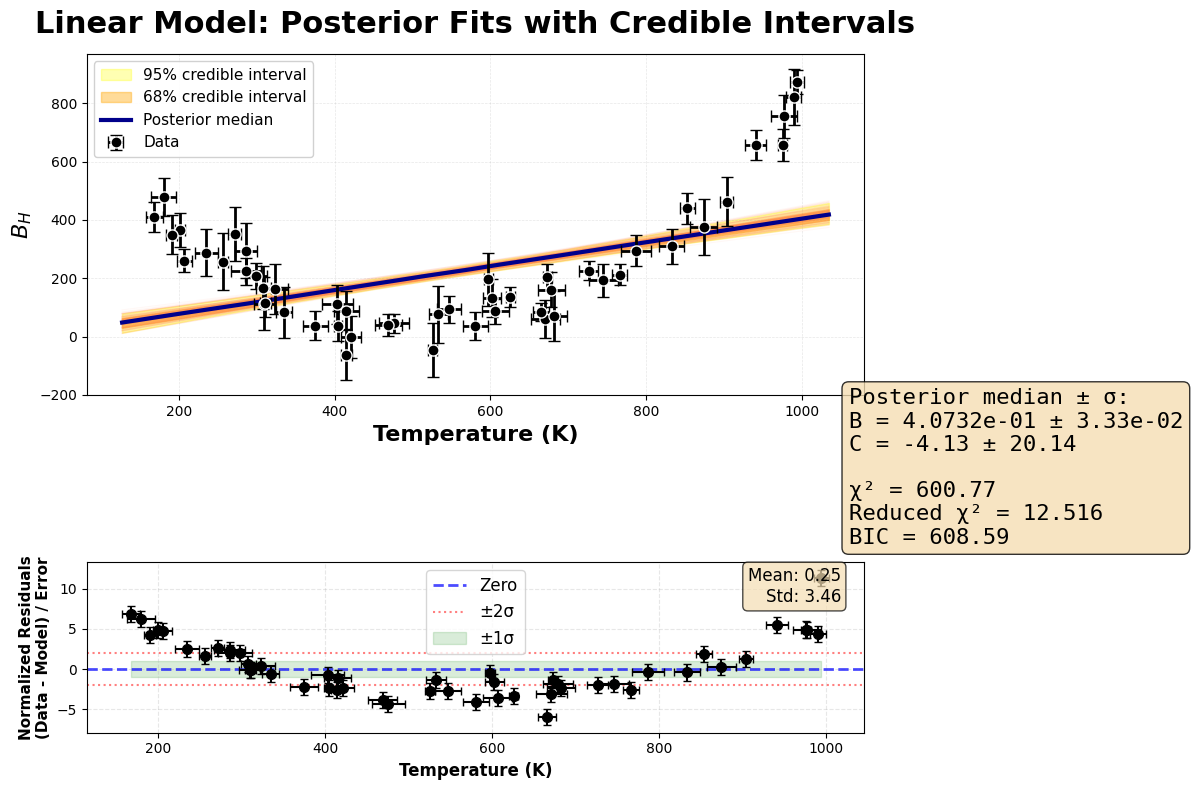

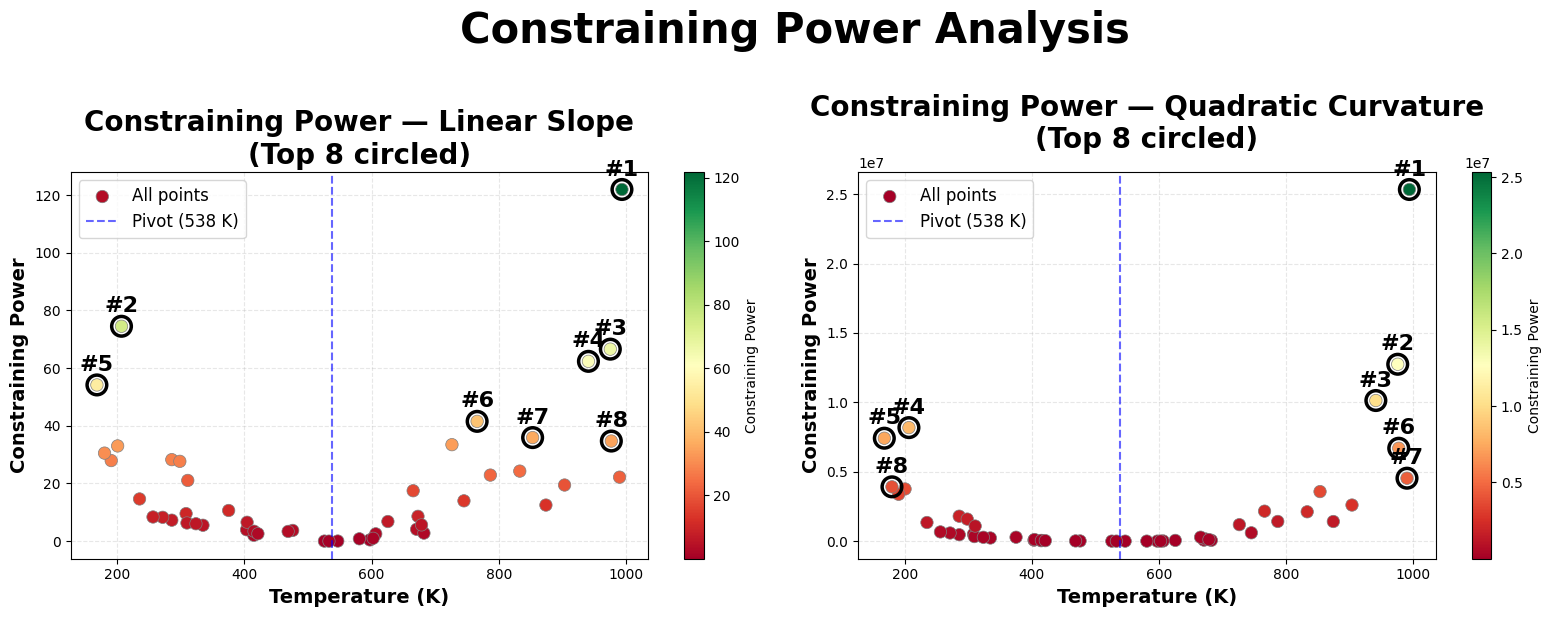


RESULTS SUMMARY

QUADRATIC MODEL  (A·T² + B·T + C)
----------------------------------------------------------------------
  A = 3.1591e-03 ± 1.45e-04
  B = -3.1976e+00 ± 1.67e-01
  C = 850.5805 ± 43.8516
  Reduced χ²          : 0.807
  BIC                 : 556.22
  Effective samples   : 15012

LINEAR MODEL  (B·T + C)
----------------------------------------------------------------------
  B = 4.0732e-01 ± 3.33e-02
  C = -4.1265 ± 20.1381
  Reduced χ²          : 12.516
  BIC                 : 1110.51
  Effective samples   : 20823

MODEL COMPARISON
----------------------------------------------------------------------
  ΔBIC (quad − lin)   : -554.29
  Interpretation      : Very strong evidence for more complex model
  Verdict             : ✓ Quadratic preferred

POSTERIOR PREDICTIVE CHECKS  (quadratic)
----------------------------------------------------------------------
  MAE                 : 47.4147
  Mean sq. residuals  : 3418.6271
  RMS observed        : 58.4690
  RMS simulated  

In [2]:
def generate_test_data(n_points=50, seed=42):
    """
    Generate synthetic quadratic data for testing.
    y = A*T^2 + B*T + C + noise
    """
    np.random.seed(seed)
    
    # TRUE MODEL PARAMETERS
    A_true = 3e-3
    B_true = -3.0
    C_true = 800.0
    
    # Generate temperatures
    T_eq = np.random.uniform(150, 1020, n_points)
    T_eq_err = np.random.uniform(5, 20, n_points)  # Not used in fitting but could be added as uncertainty on T_eq if desired
    # Generate feature heights with noise
    y_true = A_true * T_eq**2 + B_true * T_eq + C_true
    feature_height_err = np.random.uniform(30, 100, n_points)
    feature_height = y_true + np.random.normal(0, feature_height_err)
    
    # Create DataFrame
    data = pd.DataFrame({
        'Equilibrium_Temperature': T_eq,
        'Uncertainty_on_Equilibrium_Temperature': T_eq_err,
        'Feature_Height': feature_height,
        'Uncertainty_on_Feature_Height': feature_height_err
    })
    
    print("=" * 60)
    print("TRUE MODEL PARAMETERS")
    print("=" * 60)
    print(f"A (curvature) = {A_true:.6e}")
    print(f"B (linear)    = {B_true:.6f}")
    print(f"C (offset)    = {C_true:.2f}")
    print(f"Mean uncertainty: {feature_height_err.mean():.2f} ppm")
    print(f"Signal-to-noise ratio: {np.mean(y_true) / np.mean(feature_height_err):.1f}")
    
    return data, A_true, B_true, C_true

data, A_true, B_true, C_true = generate_test_data(n_points=50, seed=42)

stats = Statistics(nwalkers=64, use_parallel=False)
stats.run_all_analysis(data.values)

Burn-in:   0%|          | 0/540 [00:00<?, ?it/s]

Production: 100%|██████████| 4000/4000 [00:21<00:00, 186.31it/s]


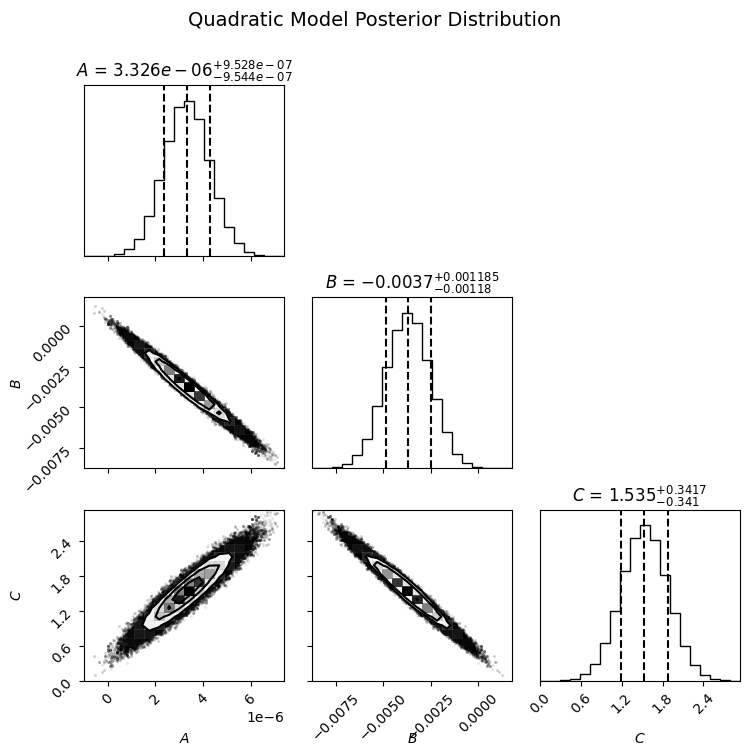

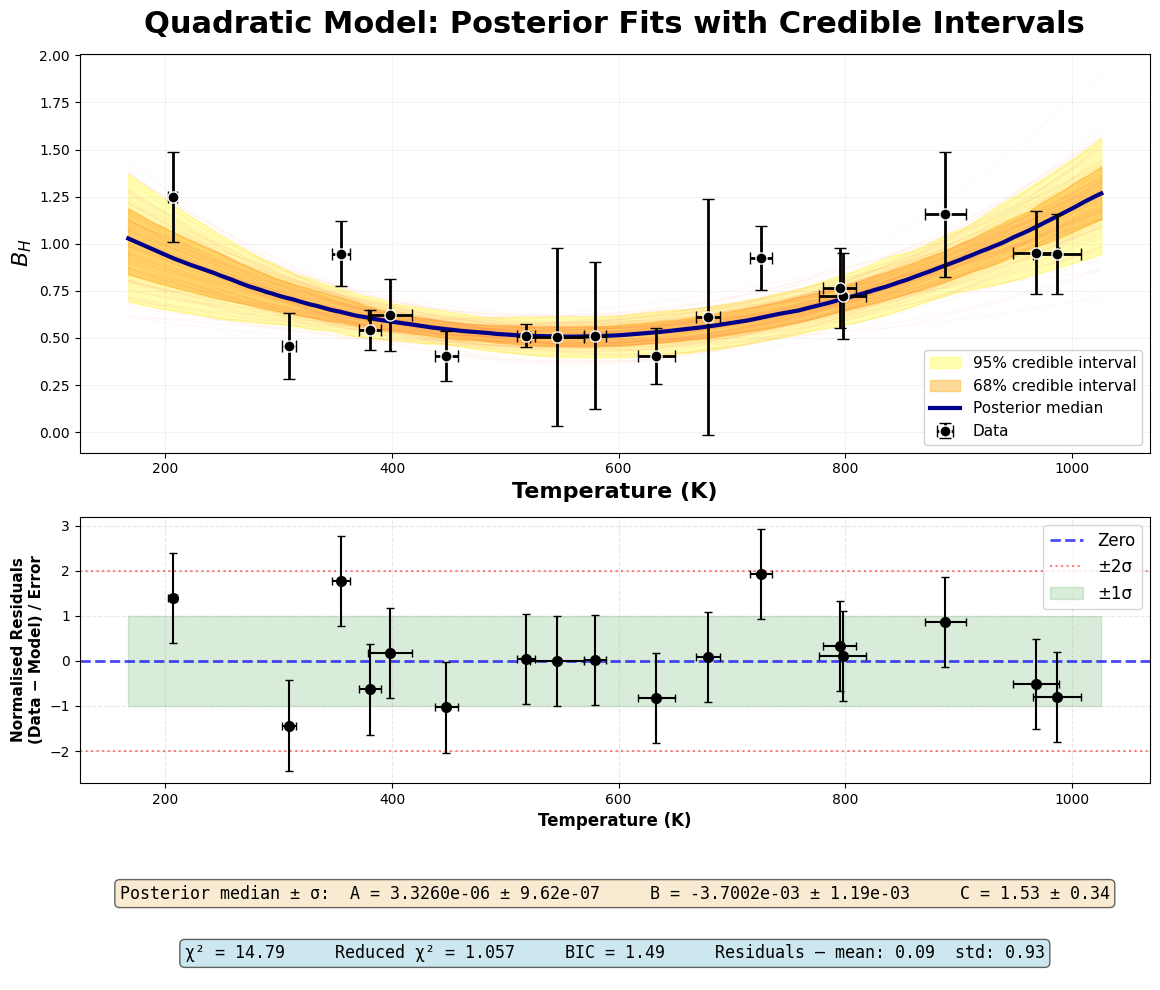

Production: 100%|██████████| 4000/4000 [00:09<00:00, 431.07it/s]


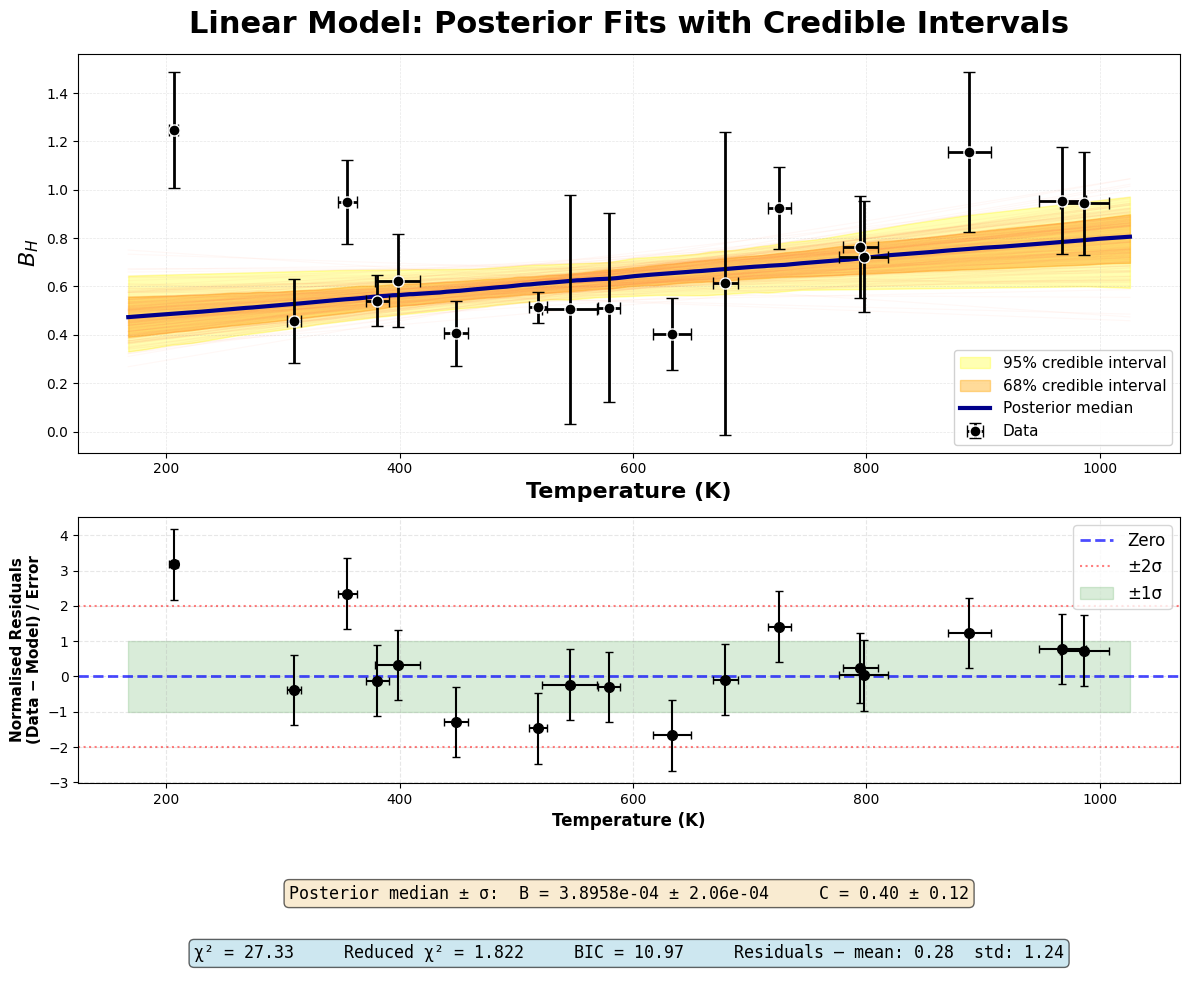

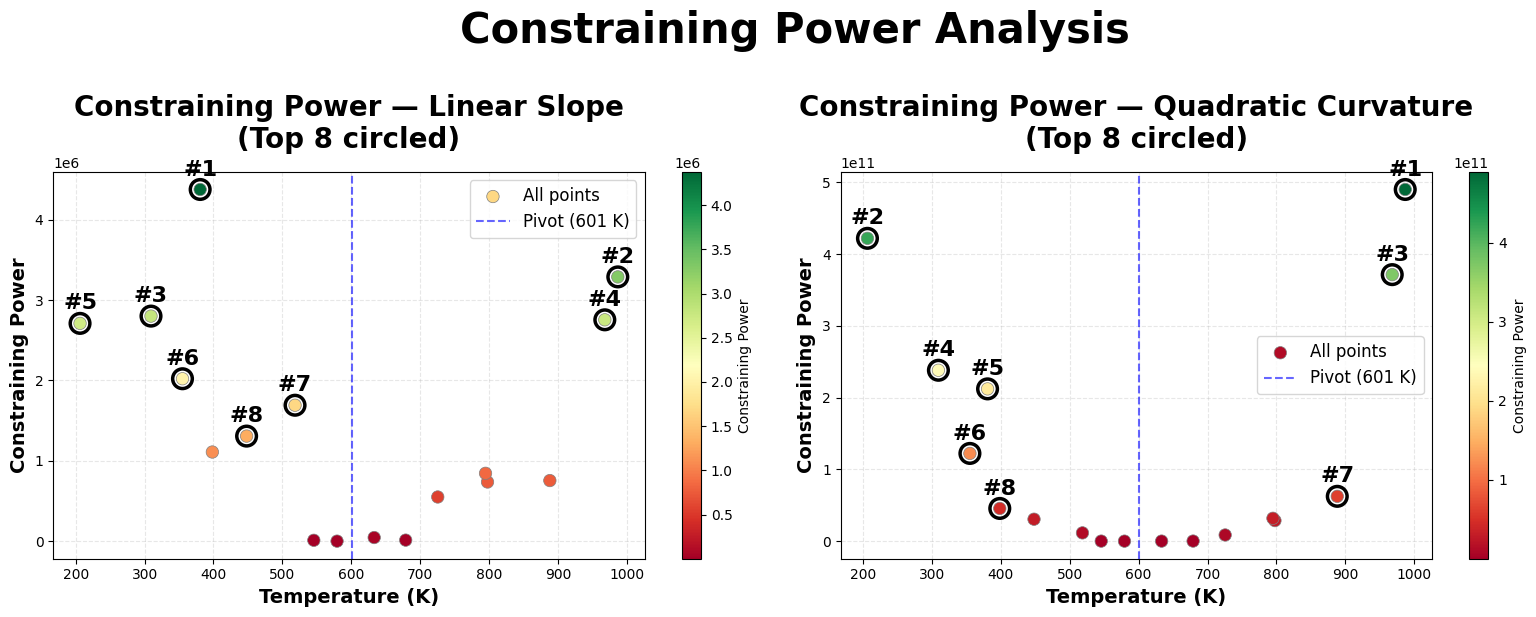


RESULTS SUMMARY

QUADRATIC MODEL  (A·T² + B·T + C)
----------------------------------------------------------------------
  A = 3.3260e-06 ± 9.62e-07
  B = -3.7002e-03 ± 1.19e-03
  C = 1.5346 ± 0.3441
  Reduced χ²          : 1.057
  BIC                 : 1.49
  Effective samples   : 23318

LINEAR MODEL  (B·T + C)
----------------------------------------------------------------------
  B = 3.8958e-04 ± 2.06e-04
  C = 0.4048 ± 0.1160
  Reduced χ²          : 1.822
  BIC                 : 10.97
  Effective samples   : 31118

MODEL COMPARISON
----------------------------------------------------------------------
  ΔBIC (quad − lin)   : -9.48
  Interpretation      : Strong evidence for more complex model
  Verdict             : ✓ Quadratic preferred

POSTERIOR PREDICTIVE CHECKS  (quadratic)
----------------------------------------------------------------------
  MAE                 : 0.1362
  Mean sq. residuals  : 0.0322
  RMS observed        : 0.1796
  RMS simulated       : 0.2663 ± 0.0712

In [32]:
# import the real data
df = pd.read_csv("../Code/Data/results/results_2026_02_27__17_46.csv")

# choosing what to fit! Feature depth vs Bh
# comment out two of three 

# Feat_depth = ['Equilibrium_Temperature', 'Uncertainty_on_Equilibrium_Temperature',
#                     'Feature_Depth', 'Feature_Depth_Error']

Feat_depth = ['Equilibrium_Temperature', 'Uncertainty_on_Equilibrium_Temperature',
                    'B_H', 'B_H_Error']


real_data = df[Feat_depth]

        # T_eq               = data[:, 0]
        # T_eq_err           = data[:, 1]
        # feature_height     = data[:, 2]
        # feature_height_err = data[:, 3]

real_data
stats = Statistics(nwalkers=64, nsteps=4000, burn=540, use_parallel=False) #custom steps and burn here!
stats.run_all_analysis(real_data.values,stats)